# 07 · Contratos — Informe de Análisis
**SURA · Analista de Analítica Legal · Reto 1 – Parte 2**

Análisis del portafolio contractual de la Gerencia de Asuntos Legales.

**Preguntas que responde este notebook:**
1. ¿Cuál es el estado actual de la operación contractual?
2. ¿Qué contratos requieren atención prioritaria?
3. ¿Dónde se concentran los riesgos de vencimiento?
4. ¿Qué compañías / tipos de contrato generan mayor carga operativa?
5. ¿Existen concentraciones de contratos próximos a expirar?
6. ¿Qué variables deberían monitorearse de forma permanente?

**Fuente:** `data/pivot_area - Data.csv` · 52,004 contratos · 22 variables

In [1]:
# ── Setup: imports, estilo, paleta, constantes ───────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Paleta consistente con nb06
C_BASE = '#2E4057'   # azul oscuro — barras neutras
C_RISK = '#C0392B'   # rojo       — alerta / vencido
C_OK   = '#1E8449'   # verde      — vigente / OK
C_WARN = '#D68910'   # ámbar      — próximo a vencer
C_NEU  = '#2471A3'   # celeste    — secundario
C_GREY = '#797D7F'   # gris       — contexto

# Constantes
DATA_PATH      = '../data/pivot_area - Data.csv'
REFERENCE_DATE = pd.Timestamp('2026-05-11')
OUT_DIR        = '../outputs'
os.makedirs(OUT_DIR, exist_ok=True)

# ── Carga y limpieza ─────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH, encoding='utf-8', sep=None, engine='python')
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

DATE_COLS = [
    'Fecha de inicio',
    'Contrato - Fecha de entrada en vigor',
    'Contrato - Fecha de expiración',
    'Propietario - Fecha de creación',
]
for col in DATE_COLS:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

# Variables derivadas clave
df['dias_hasta_venc']  = (df['Contrato - Fecha de expiración'] - REFERENCE_DATE).dt.days
df['duracion_dias']    = (
    df['Contrato - Fecha de expiración'] - df['Contrato - Fecha de entrada en vigor']
).dt.days
df['anio_inicio']      = df['Contrato - Fecha de entrada en vigor'].dt.year

# Etiquetas cortas para el tipo de contrato (quita prefijos redundantes)
df['tipo_corto'] = (df['Tipo de contrato']
    .str.replace(r'^CONTRATO DE? ?', '', regex=True)
    .str.replace(r'^CONTRATO ', '', regex=True)
    .str.strip()
    .str[:50])

print(f'Contratos cargados: {len(df):,}  |  Columnas: {df.shape[1]}')
print(f'Fecha de referencia: {REFERENCE_DATE.date()}')
print(f'Rango de expiración: {df["Contrato - Fecha de expiración"].min().date()} '
      f'→ {df["Contrato - Fecha de expiración"].max().date()}')

Contratos cargados: 52,004  |  Columnas: 25
Fecha de referencia: 2026-05-11
Rango de expiración: 1970-01-01 → 2050-12-31


---
## Sección 1 — Estado actual del portafolio
> **¿Cuál es el estado actual de la operación contractual?**

Panel de KPIs base y distribución por estado del contrato y por tipo de vigencia.

In [2]:
# ── KPIs del portafolio ───────────────────────────────────────────────
total       = len(df)
n_activos   = (df['Estado'] == 'Activo').sum()
n_finaliz   = (df['Estado'] == 'Finalizado').sum()
n_vencidos  = (df['dias_hasta_venc'] < 0).sum()
n_sin_fecha = df['Contrato - Fecha de expiración'].isna().sum()
n_sin_admin = df['Administrador de contrato'].isna().sum()

# Contratos activos con fecha ya pasada (anomalía)
activo_venc = ((df['Estado'] == 'Activo') & (df['dias_hasta_venc'] < 0)).sum()

print('─' * 55)
print('  KPIs — PORTAFOLIO CONTRACTUAL')
print('─' * 55)
print(f'  Total contratos en portafolio   {total:>8,}')
print(f'  Estado = Activo                 {n_activos:>8,}  ({n_activos/total*100:.1f}%)')
print(f'  Estado = Finalizado             {n_finaliz:>8,}  ({n_finaliz/total*100:.1f}%)')
print(f'  Fecha expiración ya pasada      {n_vencidos:>8,}  ({n_vencidos/total*100:.1f}%)')
print(f'  Activo + fecha ya vencida ⚠     {activo_venc:>8,}  (anomalía de estado)')
print(f'  Sin fecha de expiración         {n_sin_fecha:>8,}')
print(f'  Sin administrador asignado      {n_sin_admin:>8,}  ({n_sin_admin/total*100:.1f}%)')
print('─' * 55)

───────────────────────────────────────────────────────
  KPIs — PORTAFOLIO CONTRACTUAL
───────────────────────────────────────────────────────
  Total contratos en portafolio     52,004
  Estado = Activo                   22,453  (43.2%)
  Estado = Finalizado               29,551  (56.8%)
  Fecha expiración ya pasada        31,180  (60.0%)
  Activo + fecha ya vencida ⚠        1,833  (anomalía de estado)
  Sin fecha de expiración               14
  Sin administrador asignado         3,230  (6.2%)
───────────────────────────────────────────────────────


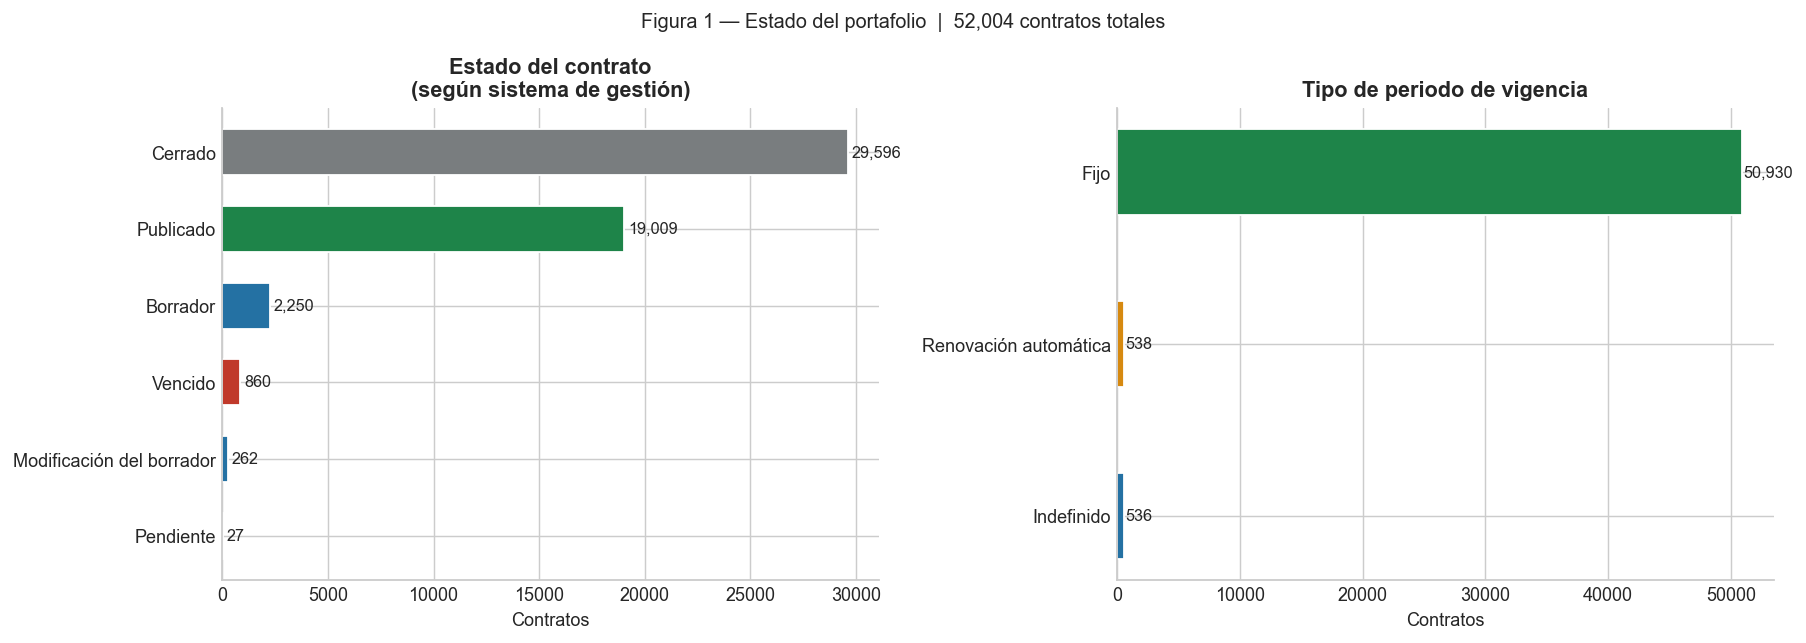

In [3]:
# ── Fig 1: Estado del contrato + Tipo de periodo (2 paneles) ────────
estado_dist = df['Estado del contrato'].value_counts()
periodo_dist = df['Tipo de periodo de vigencia'].value_counts(dropna=False)

# Paleta por estado (semáforo)
estado_colors = {
    'Publicado':               C_OK,
    'Cerrado':                 C_GREY,
    'Vencido':                 C_RISK,
    'Borrador':                C_NEU,
    'Modificación del borrador': C_NEU,
    'Pendiente':               C_WARN,
}
e_colors = [estado_colors.get(e, C_BASE) for e in estado_dist.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A — Estado del contrato
bars_e = axes[0].barh(estado_dist.index, estado_dist.values,
                      color=e_colors, edgecolor='white', height=0.6)
for bar in bars_e:
    v = int(bar.get_width())
    axes[0].text(v + 200, bar.get_y() + bar.get_height() / 2,
                 f'{v:,}', va='center', fontsize=9)
axes[0].set_xlabel('Contratos')
axes[0].set_title('Estado del contrato\n(según sistema de gestión)')
axes[0].invert_yaxis()

# Panel B — Tipo de periodo de vigencia
p_colors = [C_OK if 'Fijo' in str(p) else (C_WARN if 'Renovación' in str(p) else C_NEU)
            for p in periodo_dist.index]
bars_p = axes[1].barh(periodo_dist.index.astype(str), periodo_dist.values,
                      color=p_colors, edgecolor='white', height=0.5)
for bar in bars_p:
    v = int(bar.get_width())
    axes[1].text(v + 100, bar.get_y() + bar.get_height() / 2,
                 f'{v:,}', va='center', fontsize=9)
axes[1].set_xlabel('Contratos')
axes[1].set_title('Tipo de periodo de vigencia')
axes[1].invert_yaxis()

plt.suptitle(f'Figura 1 — Estado del portafolio  |  {total:,} contratos totales', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/c_fig1_estado_portafolio.png', bbox_inches='tight')
plt.show()

---
## Sección 2 — Contratos próximos a vencer y riesgo de continuidad
> **¿Qué contratos requieren atención prioritaria? ¿Dónde se concentran los riesgos de vencimiento?**

In [4]:
# ── Categorización de urgencia de vencimiento ───────────────────────
# Solo contratos con fecha válida
df_exp = df[df['Contrato - Fecha de expiración'].notna()].copy()

def cat_venc(dias):
    if dias < 0:           return 'Vencido'
    elif dias <= 30:       return 'Vence ≤ 30 días'
    elif dias <= 90:       return 'Vence 31–90 días'
    elif dias <= 180:      return 'Vence 91–180 días'
    else:                  return 'Vigente > 180 días'

CAT_ORDER  = ['Vencido', 'Vence ≤ 30 días', 'Vence 31–90 días',
              'Vence 91–180 días', 'Vigente > 180 días']
CAT_COLORS = [C_RISK, '#E74C3C', C_WARN, '#F4D03F', C_OK]

df_exp['cat_venc'] = df_exp['dias_hasta_venc'].apply(cat_venc)
resumen_venc = df_exp['cat_venc'].value_counts().reindex(CAT_ORDER, fill_value=0)

# Solo activos — para la vista operativa relevante
activos_df   = df[df['Estado'] == 'Activo'].copy()
activos_exp  = activos_df[activos_df['Contrato - Fecha de expiración'].notna()].copy()
activos_exp['cat_venc'] = activos_exp['dias_hasta_venc'].apply(cat_venc)
resumen_activos = activos_exp['cat_venc'].value_counts().reindex(CAT_ORDER, fill_value=0)

print('Distribución de vencimiento — TODOS los contratos:')
for cat, n in resumen_venc.items():
    print(f'  {cat:<22}: {n:>6,}  ({n/len(df_exp)*100:.1f}%)')
print()
print('Distribución de vencimiento — solo ACTIVOS:')
for cat, n in resumen_activos.items():
    print(f'  {cat:<22}: {n:>6,}  ({n/len(activos_exp)*100:.1f}%)')

n_urgentes_30 = resumen_activos['Vence ≤ 30 días']
n_urgentes_90 = resumen_activos['Vence ≤ 30 días'] + resumen_activos['Vence 31–90 días']
n_activo_venc = resumen_activos['Vencido']
print(f'\n→ Activos que vencen ≤ 30 días:  {n_urgentes_30:,}')
print(f'→ Activos que vencen ≤ 90 días:  {n_urgentes_90:,}')
print(f'→ Activos con fecha ya pasada:   {n_activo_venc:,}  (anomalía de estado)')

Distribución de vencimiento — TODOS los contratos:
  Vencido               : 31,180  (60.0%)
  Vence ≤ 30 días       :    927  (1.8%)
  Vence 31–90 días      :  2,723  (5.2%)
  Vence 91–180 días     :  3,423  (6.6%)
  Vigente > 180 días    : 13,737  (26.4%)

Distribución de vencimiento — solo ACTIVOS:
  Vencido               :  1,833  (8.2%)
  Vence ≤ 30 días       :    898  (4.0%)
  Vence 31–90 días      :  2,685  (12.0%)
  Vence 91–180 días     :  3,393  (15.1%)
  Vigente > 180 días    : 13,630  (60.7%)

→ Activos que vencen ≤ 30 días:  898
→ Activos que vencen ≤ 90 días:  3,583
→ Activos con fecha ya pasada:   1,833  (anomalía de estado)


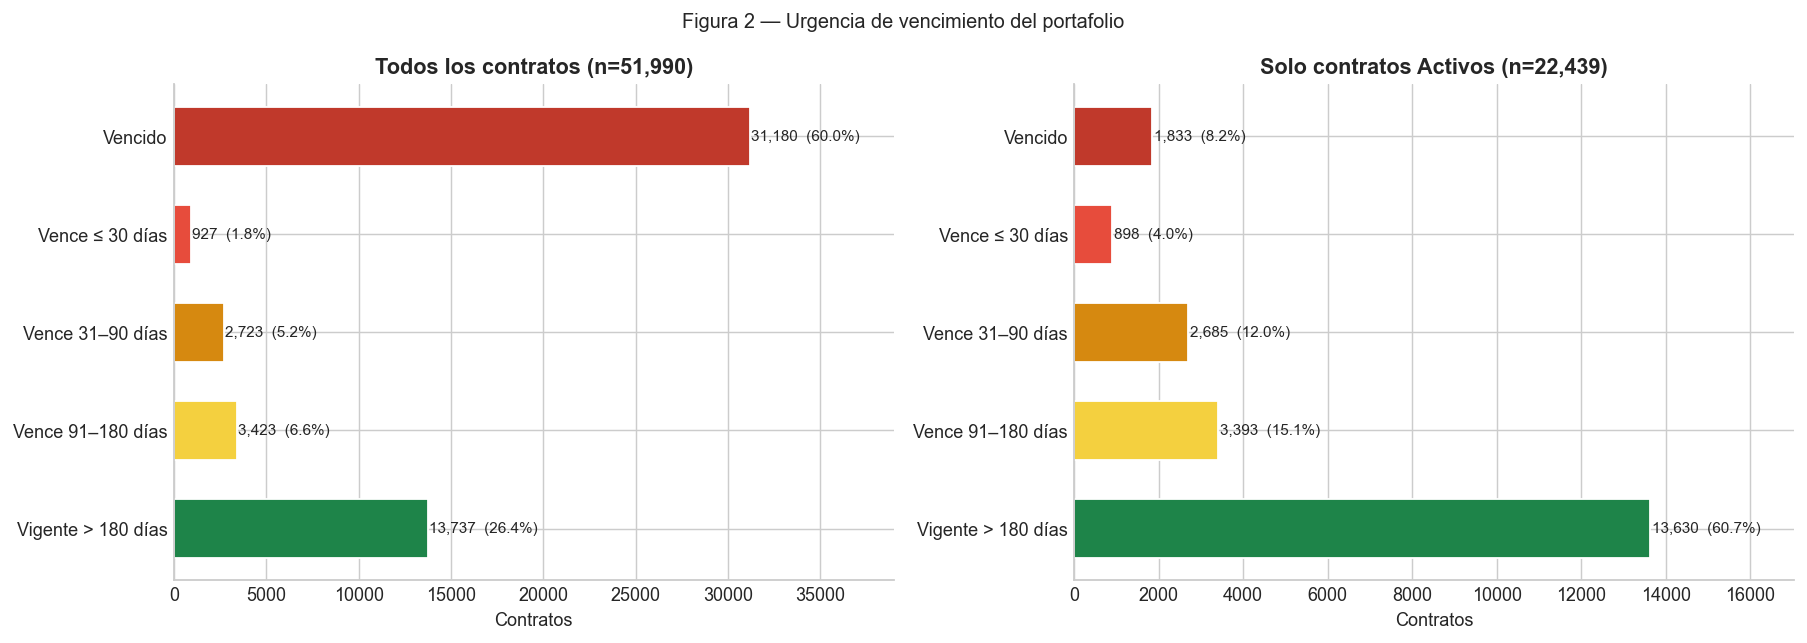

In [5]:
# ── Fig 2: Urgencia de vencimiento — todos vs activos (2 paneles) ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, titulo in [
    (axes[0], resumen_venc,    f'Todos los contratos (n={len(df_exp):,})'),
    (axes[1], resumen_activos, f'Solo contratos Activos (n={len(activos_exp):,})'),
]:
    bars = ax.barh(data.index[::-1], data.values[::-1],
                   color=CAT_COLORS[::-1], edgecolor='white', height=0.6)
    for bar in bars:
        v = int(bar.get_width())
        pct = v / data.sum() * 100 if data.sum() > 0 else 0
        ax.text(v + 50, bar.get_y() + bar.get_height() / 2,
                f'{v:,}  ({pct:.1f}%)', va='center', fontsize=8.5)
    ax.set_xlabel('Contratos')
    ax.set_title(titulo)
    ax.set_xlim(0, data.max() * 1.25)

plt.suptitle('Figura 2 — Urgencia de vencimiento del portafolio', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/c_fig2_urgencia_vencimiento.png', bbox_inches='tight')
plt.show()

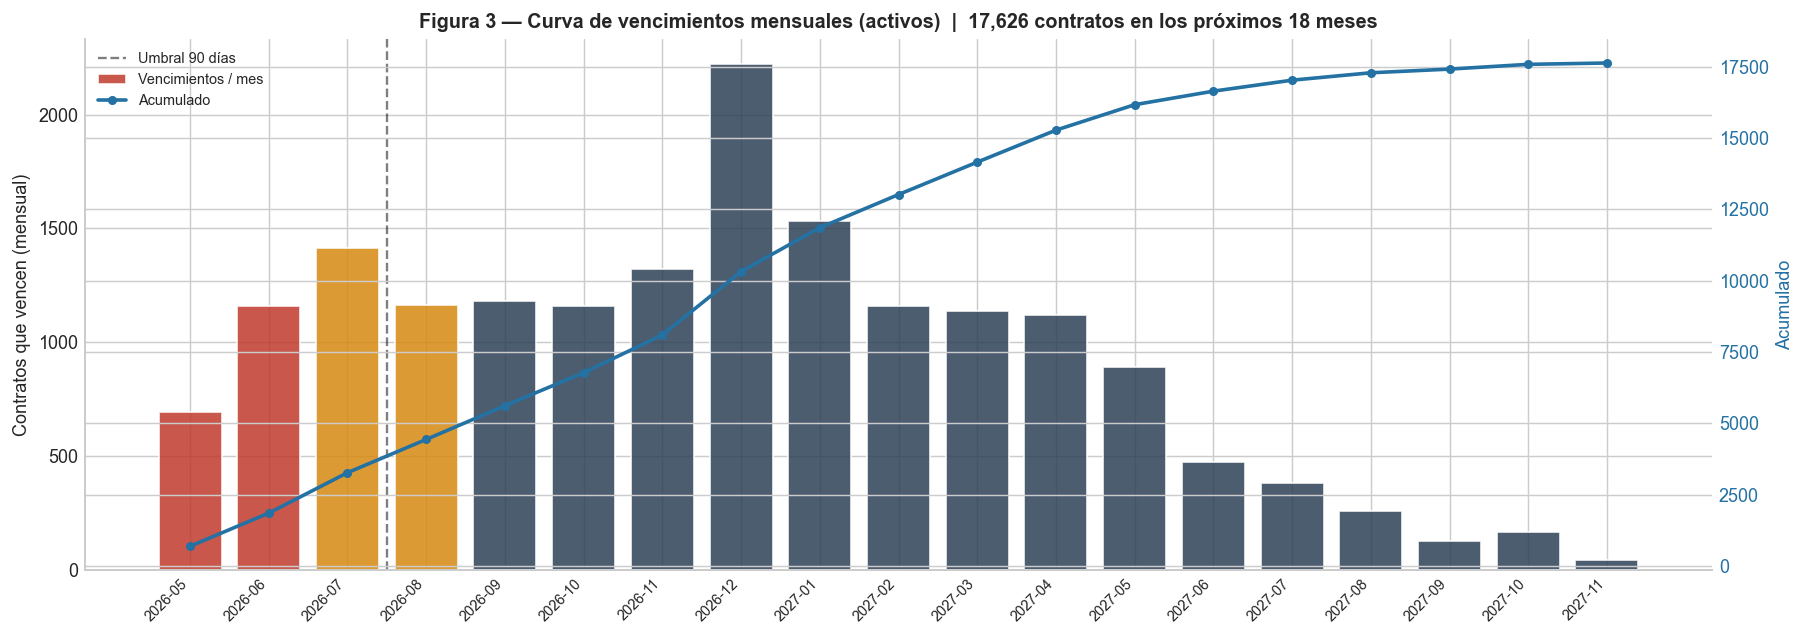

In [6]:
# ── Fig 3: Curva de vencimientos mes a mes (próximos 18 meses) ──────
proximos = activos_exp[
    (activos_exp['dias_hasta_venc'] >= 0) &
    (activos_exp['dias_hasta_venc'] <= 548)   # ~18 meses
].copy()

proximos['mes_venc'] = proximos['Contrato - Fecha de expiración'].dt.to_period('M')
venc_mes  = proximos['mes_venc'].value_counts().sort_index()
venc_acum = venc_mes.cumsum()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

# Barras mensuales — color según urgencia
bar_colors_m = [
    C_RISK if str(p) <= str(pd.Period(REFERENCE_DATE, 'M') + 1) else
    (C_WARN if str(p) <= str(pd.Period(REFERENCE_DATE, 'M') + 3) else C_BASE)
    for p in venc_mes.index
]
ax1.bar(range(len(venc_mes)), venc_mes.values,
        color=bar_colors_m, edgecolor='white', alpha=0.85, label='Vencimientos / mes')
ax2.plot(range(len(venc_mes)), venc_acum.values,
         color=C_NEU, lw=2, marker='o', markersize=4, label='Acumulado')

# Línea de referencia al mes 3 (umbral 90 días)
ax1.axvline(2.5, color='black', linestyle='--', lw=1.3, alpha=0.5, label='Umbral 90 días')

ax1.set_xticks(range(len(venc_mes)))
ax1.set_xticklabels([str(p) for p in venc_mes.index], rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Contratos que vencen (mensual)')
ax2.set_ylabel('Acumulado', color=C_NEU)
ax2.tick_params(axis='y', labelcolor=C_NEU)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

ax1.set_title(
    f'Figura 3 — Curva de vencimientos mensuales (activos)  |  '
    f'{len(proximos):,} contratos en los próximos 18 meses',
    fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/c_fig3_curva_vencimientos.png', bbox_inches='tight')
plt.show()

---
## Sección 3 — Concentración y carga operativa
> **¿Qué departamentos y tipos de contrato generan mayor carga? ¿Hay dependencia de proveedores?**

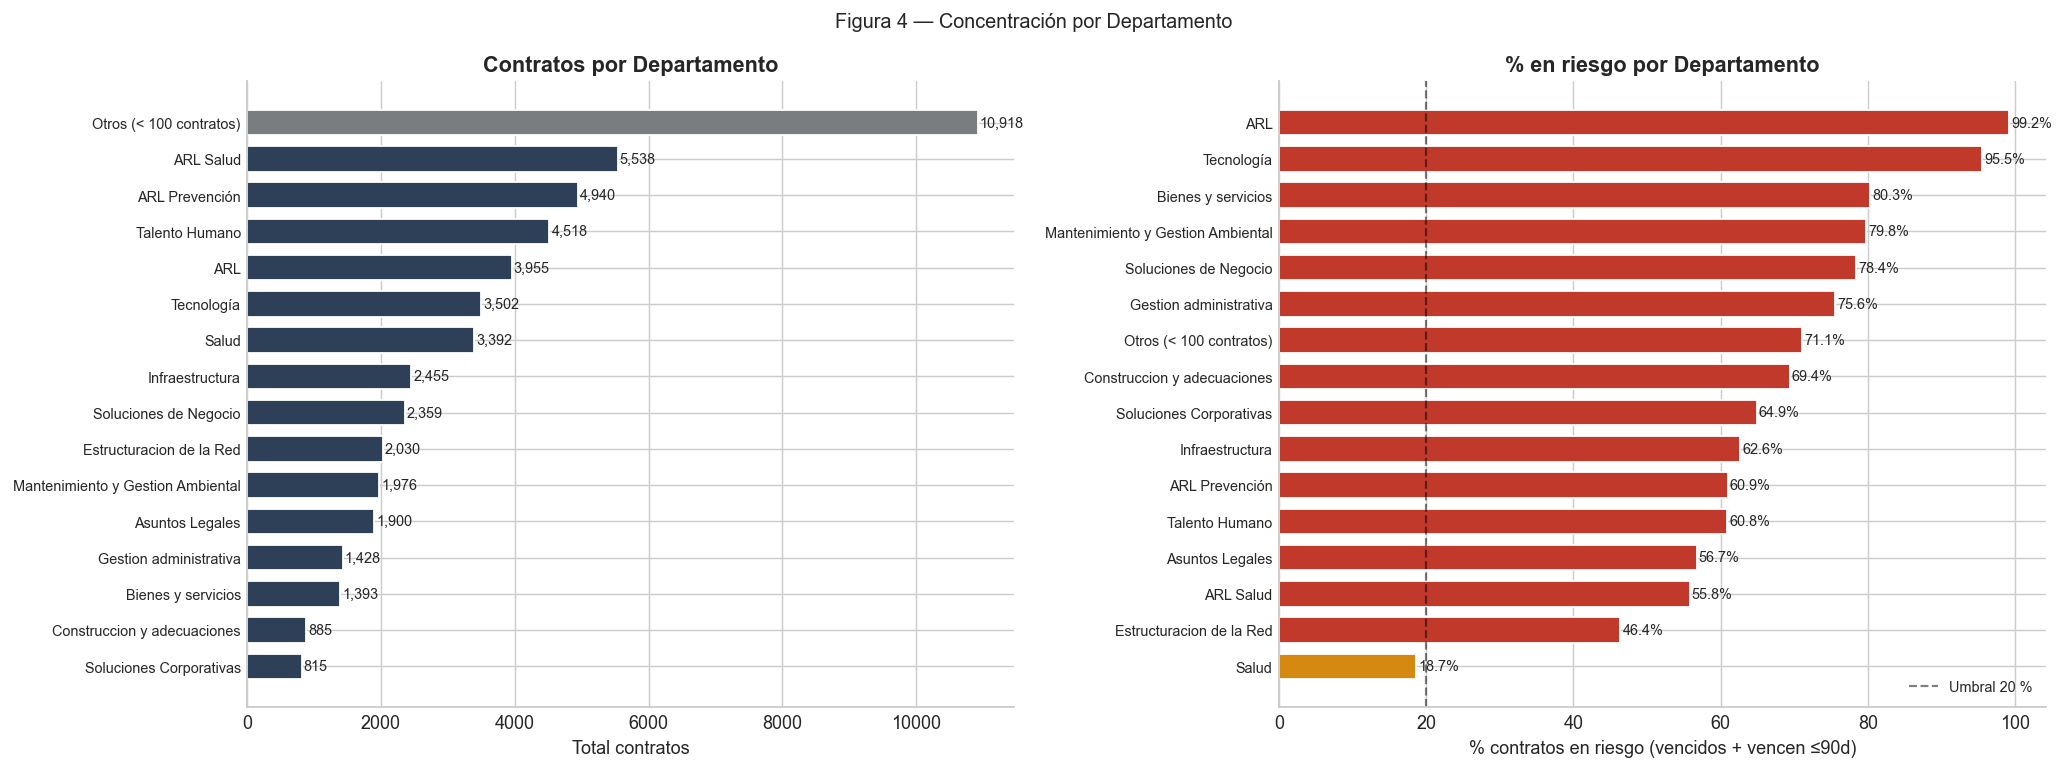

In [7]:
# ── Fig 4: Top departamentos — volumen total + % en riesgo ──────────
# Umbral de muestra representativa para nivel de departamento
MIN_N_DEPT = 100

dept = (df.groupby('Organización - Departamento')
         .agg(
             total       = ('Contrato - ID de contrato', 'count'),
             vencidos    = ('dias_hasta_venc', lambda x: (x < 0).sum()),
             proximos_90 = ('dias_hasta_venc', lambda x: ((x >= 0) & (x <= 90)).sum()),
         )
         .assign(pct_riesgo=lambda d: (d['vencidos'] + d['proximos_90']) / d['total'] * 100)
         .sort_values('total', ascending=False)
)

# Top 15 con n >= MIN_N_DEPT; agrupa el resto en "Otros"
top_dept = dept[dept['total'] >= MIN_N_DEPT].head(15)
otros    = dept[~dept.index.isin(top_dept.index)]
if len(otros) > 0:
    otros_row = pd.DataFrame({
        'total':       [otros['total'].sum()],
        'vencidos':    [otros['vencidos'].sum()],
        'proximos_90': [otros['proximos_90'].sum()],
        'pct_riesgo':  [(otros['vencidos'].sum() + otros['proximos_90'].sum()) /
                        otros['total'].sum() * 100 if otros['total'].sum() > 0 else 0],
    }, index=['Otros (< 100 contratos)'])
    top_dept = pd.concat([top_dept, otros_row])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A — volumen total
top_plot = top_dept.sort_values('total')
bar_cols = [C_GREY if 'Otros' in str(i) else C_BASE for i in top_plot.index]
bars_d = axes[0].barh(top_plot.index, top_plot['total'],
                      color=bar_cols, edgecolor='white', height=0.7)
for bar in bars_d:
    v = int(bar.get_width())
    axes[0].text(v + 30, bar.get_y() + bar.get_height() / 2,
                 f'{v:,}', va='center', fontsize=8)
axes[0].set_xlabel('Total contratos')
axes[0].set_title('Contratos por Departamento')
axes[0].tick_params(axis='y', labelsize=8)

# Panel B — % en riesgo (vencido + próximos 90d)
top_riesgo = top_plot.sort_values('pct_riesgo')
riesgo_cols = [C_RISK if v > 20 else (C_WARN if v > 10 else C_OK)
               for v in top_riesgo['pct_riesgo']]
axes[1].barh(top_riesgo.index, top_riesgo['pct_riesgo'],
             color=riesgo_cols, edgecolor='white', height=0.7)
axes[1].axvline(20, color='black', linestyle='--', lw=1.2, alpha=0.5, label='Umbral 20 %')
for i, v in enumerate(top_riesgo['pct_riesgo']):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8)
axes[1].set_xlabel('% contratos en riesgo (vencidos + vencen ≤90d)')
axes[1].set_title('% en riesgo por Departamento')
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='y', labelsize=8)

plt.suptitle('Figura 4 — Concentración por Departamento', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/c_fig4_concentracion_departamento.png', bbox_inches='tight')
plt.show()

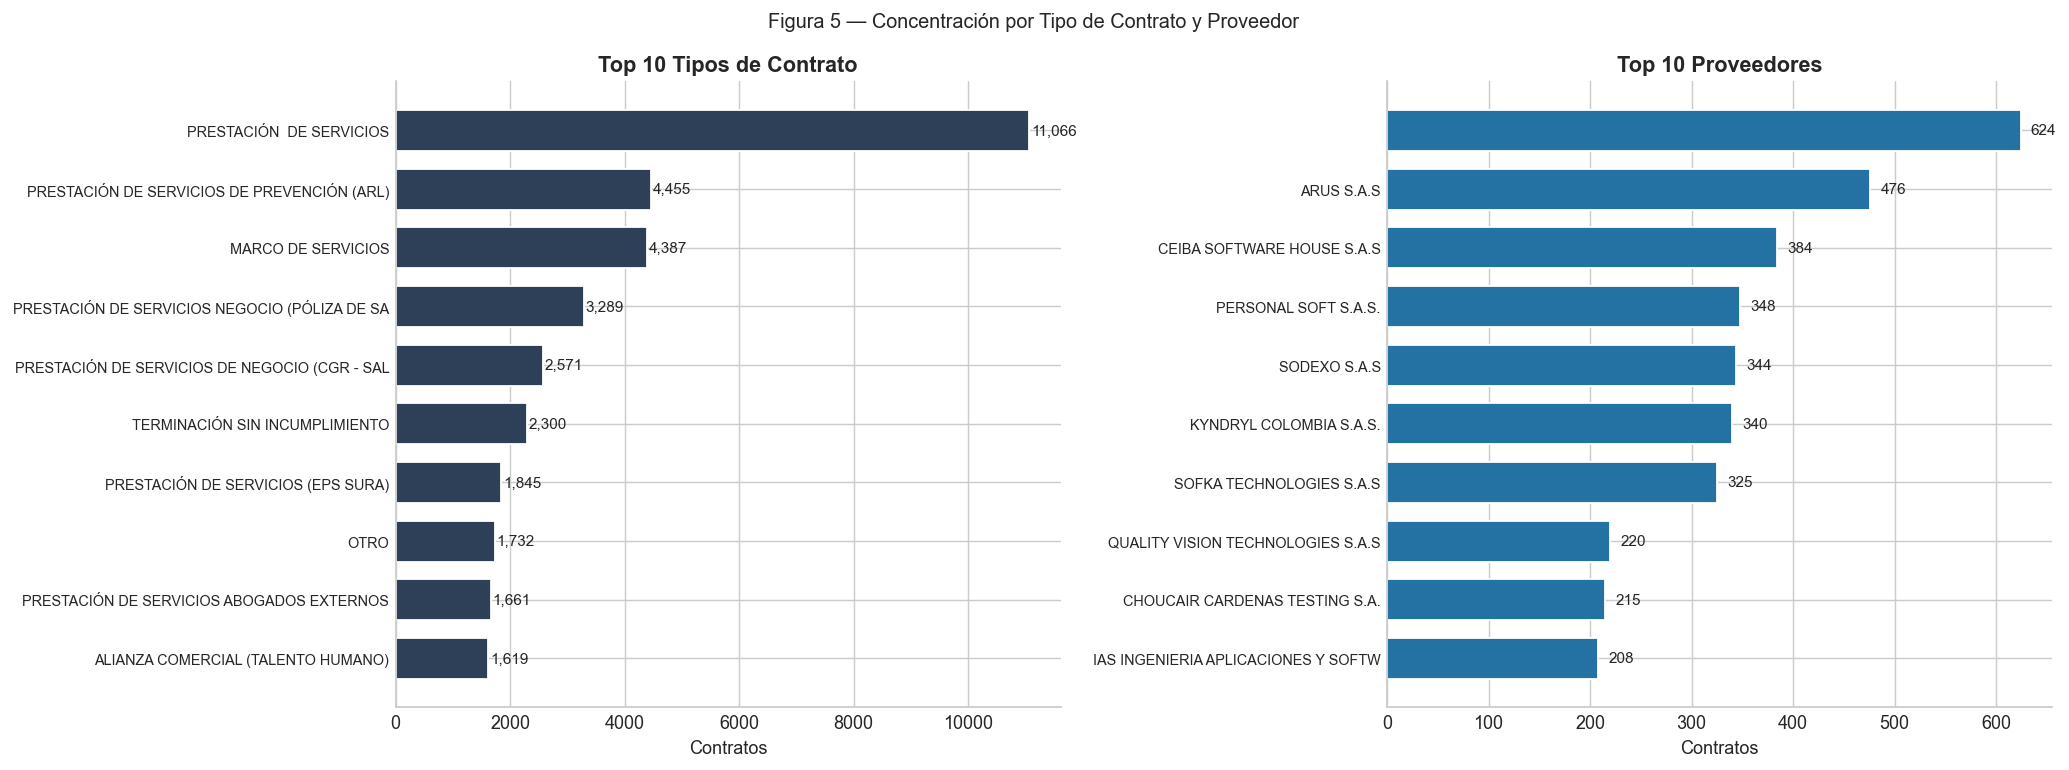


→ Proveedor #1 ( ): 624 contratos (1.2% del total)
→ Top 3 proveedores concentran: 1,484 contratos (2.9%)


In [8]:
# ── Fig 5: Top tipos de contrato + top proveedores ──────────────────
TOP_N = 10

tipo_df = df['Tipo de contrato'].value_counts().head(TOP_N)
prov_col = 'Partes afectadas - Nombre del proveedor (L1)'
prov_df  = (df[df[prov_col].notna() & (df[prov_col] != '')]
            [prov_col].value_counts().head(TOP_N))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A — tipos de contrato (etiqueta corta)
tipo_labels = [t.replace('CONTRATO DE ', '').replace('CONTRATO ', '')[:45]
               for t in tipo_df.index]
axes[0].barh(tipo_labels[::-1], tipo_df.values[::-1],
             color=C_BASE, edgecolor='white', height=0.7)
for i, v in enumerate(tipo_df.values[::-1]):
    axes[0].text(v + 30, i, f'{v:,}', va='center', fontsize=8.5)
axes[0].set_xlabel('Contratos')
axes[0].set_title(f'Top {TOP_N} Tipos de Contrato')
axes[0].tick_params(axis='y', labelsize=8)

# Panel B — proveedores
prov_labels = [str(p)[:50] for p in prov_df.index]
axes[1].barh(prov_labels[::-1], prov_df.values[::-1],
             color=C_NEU, edgecolor='white', height=0.7)
for i, v in enumerate(prov_df.values[::-1]):
    axes[1].text(v + 10, i, f'{v:,}', va='center', fontsize=8.5)
axes[1].set_xlabel('Contratos')
axes[1].set_title(f'Top {TOP_N} Proveedores')
axes[1].tick_params(axis='y', labelsize=8)

plt.suptitle('Figura 5 — Concentración por Tipo de Contrato y Proveedor', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/c_fig5_tipo_proveedor.png', bbox_inches='tight')
plt.show()

# Indicador de concentración de proveedores
top1_pct = prov_df.iloc[0] / len(df) * 100
top3_pct = prov_df.iloc[:3].sum() / len(df) * 100
print(f'\n→ Proveedor #1 ({prov_df.index[0]}): {prov_df.iloc[0]:,} contratos ({top1_pct:.1f}% del total)')
print(f'→ Top 3 proveedores concentran: {prov_df.iloc[:3].sum():,} contratos ({top3_pct:.1f}%)')

---
## Sección 4 — Anomalías e integridad del dato
> **¿Qué inconsistencias existen en el portafolio? ¿Qué variables requieren depuración antes de automatizar?**

In [9]:
# ── Cuantificación de anomalías ──────────────────────────────────────
n_total = len(df)

# A1 — Activos con fecha ya vencida
a1 = ((df['Estado'] == 'Activo') &
      (df['Contrato - Fecha de expiración'].notna()) &
      (df['dias_hasta_venc'] < 0)).sum()

# A2 — Fecha inicio posterior a fecha expiración (lógicamente imposible)
a2 = (df['Contrato - Fecha de entrada en vigor'].notna() &
      df['Contrato - Fecha de expiración'].notna() &
      (df['Contrato - Fecha de entrada en vigor'] >
       df['Contrato - Fecha de expiración'])).sum()

# A3 — Sin administrador asignado
a3 = df['Administrador de contrato'].isna().sum()

# A4 — Sin fecha de expiración
a4 = df['Contrato - Fecha de expiración'].isna().sum()

# A5 — Duración anómala (< 1 día ó > 10 años)
a5_short = (df['duracion_dias'].notna() & (df['duracion_dias'] < 1)).sum()
a5_long  = (df['duracion_dias'].notna() & (df['duracion_dias'] > 3650)).sum()
a5 = a5_short + a5_long

anomalias = {
    'Activo con fecha ya\nvencida (estado inconsistente)': a1,
    'Fecha inicio >\nfecha expiración':                    a2,
    'Sin administrador\nasignado':                         a3,
    'Sin fecha de\nexpiración registrada':                 a4,
    'Duración anómala\n(< 1 día o > 10 años)':            a5,
}

print('RESUMEN DE ANOMALÍAS E INCONSISTENCIAS')
print('─' * 55)
for label, n in anomalias.items():
    label_clean = label.replace('\n', ' ')
    print(f'  {label_clean:<45}: {n:>6,}  ({n/n_total*100:.1f}%)')
total_anom = len({i for k, v in [
    ('a1', df[((df['Estado'] == 'Activo') & (df['dias_hasta_venc'] < 0))].index),
    ('a2', df[(df['Contrato - Fecha de entrada en vigor'] >
               df['Contrato - Fecha de expiración'])].index),
    ('a3', df[df['Administrador de contrato'].isna()].index),
    ('a4', df[df['Contrato - Fecha de expiración'].isna()].index),
] for i in v})
print(f'\n→ Total contratos con al menos 1 anomalía: ~{total_anom:,}  ({total_anom/n_total*100:.1f}%)')

RESUMEN DE ANOMALÍAS E INCONSISTENCIAS
───────────────────────────────────────────────────────
  Activo con fecha ya vencida (estado inconsistente):  1,833  (3.5%)
  Fecha inicio > fecha expiración              :    883  (1.7%)
  Sin administrador asignado                   :  3,230  (6.2%)
  Sin fecha de expiración registrada           :     14  (0.0%)
  Duración anómala (< 1 día o > 10 años)       :  3,180  (6.1%)

→ Total contratos con al menos 1 anomalía: ~5,481  (10.5%)


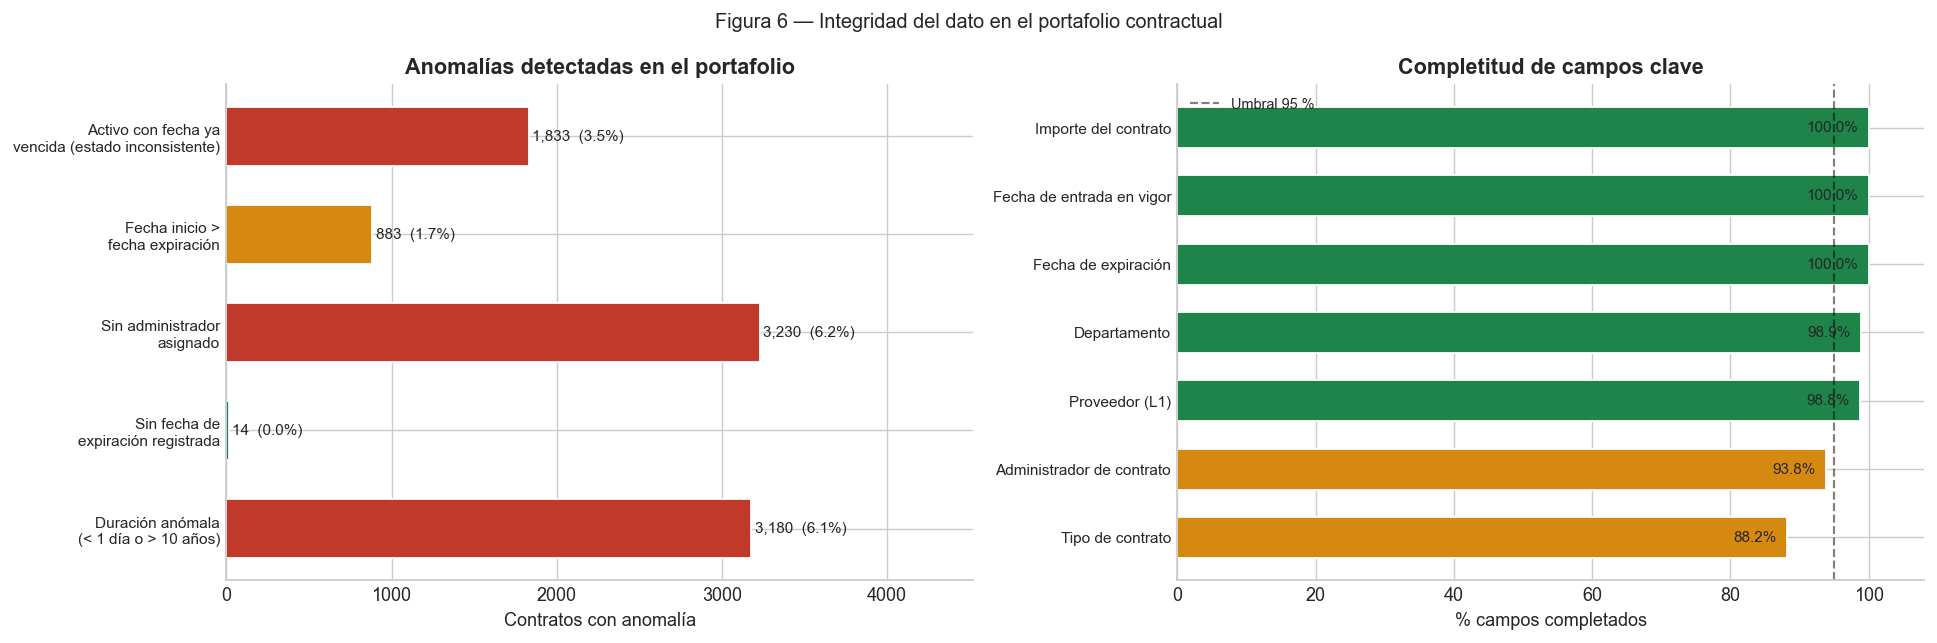

In [10]:
# ── Fig 6: Panel de anomalías (barras + completitud por columna) ─────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel A — anomalías cuantificadas
labels_anom = list(anomalias.keys())
values_anom = list(anomalias.values())
# Invertir para mostrar mayor arriba
labels_r = labels_anom[::-1]
values_r = values_anom[::-1]
bar_c = [C_RISK if v > 1000 else (C_WARN if v > 200 else C_OK) for v in values_r]
bars_a = axes[0].barh(labels_r, values_r, color=bar_c, edgecolor='white', height=0.6)
for bar in bars_a:
    v = int(bar.get_width())
    pct = v / n_total * 100
    axes[0].text(v + 20, bar.get_y() + bar.get_height() / 2,
                 f'{v:,}  ({pct:.1f}%)', va='center', fontsize=8.5)
axes[0].set_xlabel('Contratos con anomalía')
axes[0].set_title('Anomalías detectadas en el portafolio')
axes[0].tick_params(axis='y', labelsize=8.5)
axes[0].set_xlim(0, max(values_anom) * 1.4)

# Panel B — completitud de campos clave
campos = {
    'Tipo de contrato':                    'Tipo de contrato',
    'Departamento':                        'Organización - Departamento',
    'Fecha de entrada en vigor':           'Contrato - Fecha de entrada en vigor',
    'Fecha de expiración':                 'Contrato - Fecha de expiración',
    'Administrador de contrato':           'Administrador de contrato',
    'Importe del contrato':                'sum(Importe del contrato)',
    'Proveedor (L1)':                      'Partes afectadas - Nombre del proveedor (L1)',
}
completitud = {}
for label, col in campos.items():
    if col in df.columns:
        filled = df[col].notna() & (df[col].astype(str).str.strip() != '') & (df[col].astype(str) != 'nan')
        completitud[label] = filled.sum() / n_total * 100
    else:
        completitud[label] = 0

comp_sorted = dict(sorted(completitud.items(), key=lambda x: x[1]))
comp_colors = [C_RISK if v < 80 else (C_WARN if v < 95 else C_OK) for v in comp_sorted.values()]
bars_c = axes[1].barh(list(comp_sorted.keys()), list(comp_sorted.values()),
                      color=comp_colors, edgecolor='white', height=0.6)
for bar in bars_c:
    v = bar.get_width()
    axes[1].text(v - 1.5 if v > 5 else v + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{v:.1f}%', va='center', ha='right' if v > 5 else 'left', fontsize=8.5)
axes[1].axvline(95, color='black', linestyle='--', lw=1.2, alpha=0.5, label='Umbral 95 %')
axes[1].set_xlabel('% campos completados')
axes[1].set_title('Completitud de campos clave')
axes[1].set_xlim(0, 108)
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='y', labelsize=8.5)

plt.suptitle('Figura 6 — Integridad del dato en el portafolio contractual', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/c_fig6_anomalias_calidad.png', bbox_inches='tight')
plt.show()

---
## Sección 5 — Exportar contratos críticos y tabla de alertas
> Exporta los contratos activos con mayor urgencia de atención para lista de trabajo del equipo legal.

In [11]:
# ── Exportar lista de contratos críticos ─────────────────────────────
# Prioridad: activos con fecha vencida ó vencen ≤ 90 días
criticos = activos_df[
    activos_df['Contrato - Fecha de expiración'].notna() &
    (activos_df['dias_hasta_venc'] <= 90)
].copy()

criticos['alerta'] = criticos['dias_hasta_venc'].apply(
    lambda x: 'VENCIDO'   if x < 0      else
              'CRÍTICO'   if x <= 30     else
              'URGENTE'   if x <= 60     else 'PRIORITARIO'
)

# Ordenar: vencidos primero, luego por días creciente
criticos_export = criticos.sort_values(['alerta', 'dias_hasta_venc'])

# Seleccionar columnas útiles para el equipo
cols_export = [
    'Contrato - ID de contrato',
    'Tipo de contrato',
    'Organización - Departamento',
    'Partes afectadas - Nombre del proveedor (L1)',
    'Administrador de contrato',
    'Contrato - Fecha de entrada en vigor',
    'Contrato - Fecha de expiración',
    'dias_hasta_venc',
    'alerta',
]
cols_export = [c for c in cols_export if c in criticos_export.columns]

out_path = f'{OUT_DIR}/contratos_criticos_90dias.csv'
criticos_export[cols_export].to_csv(out_path, index=False, encoding='utf-8-sig')

print(f'✓ Contratos críticos exportados: {out_path}')
print(f'  Total: {len(criticos_export):,} contratos')
print()
print(criticos_export['alerta'].value_counts().to_string())
print(f'\n→ Top 5 departamentos con mayor exposición:')
print(criticos_export['Organización - Departamento'].value_counts().head(5).to_string())

✓ Contratos críticos exportados: ../outputs/contratos_criticos_90dias.csv
  Total: 5,416 contratos

alerta
VENCIDO        1833
URGENTE        1495
PRIORITARIO    1190
CRÍTICO         898

→ Top 5 departamentos con mayor exposición:
Organización - Departamento
ARL Prevención              815
Talento Humano              441
Estructuracion de la Red    421
ARL Salud                   413
Salud                       411


---
## Sección 6 — Panel ejecutivo de KPIs
> Síntesis visual de los indicadores clave del portafolio para presentación a dirección.

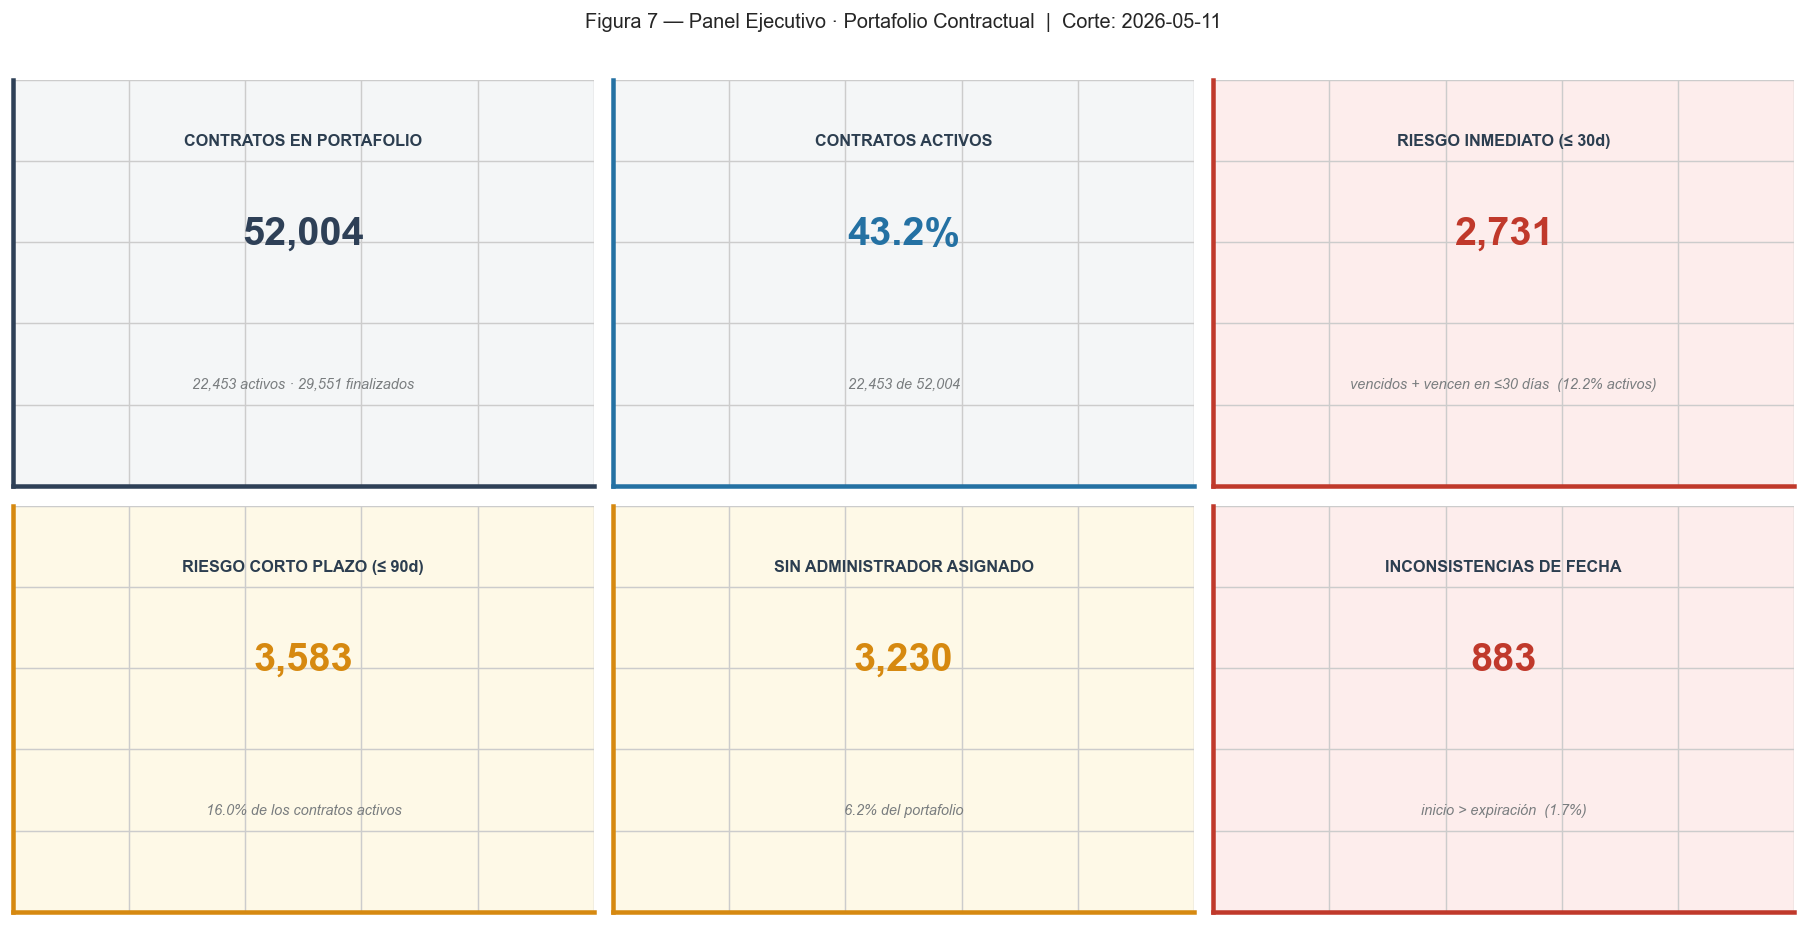

In [12]:
# ── Fig 7: Panel de KPI cards ejecutivos ────────────────────────────
def kpi_card(ax, titulo, valor, subtitulo='', color=C_BASE, fondo='#F4F6F7'):
    ax.set_facecolor(fondo)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2.5)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax.text(0.5, 0.62, valor,   ha='center', va='center', fontsize=22,
            fontweight='bold', color=color)
    ax.text(0.5, 0.85, titulo,  ha='center', va='center', fontsize=9,
            fontweight='bold', color='#2C3E50')
    ax.text(0.5, 0.25, subtitulo, ha='center', va='center', fontsize=8,
            color=C_GREY, style='italic')

# Calcular valores actualizados
pct_activos  = n_activos / total * 100
pct_urgente  = (resumen_activos['Vencido'] + resumen_activos['Vence ≤ 30 días']) / n_activos * 100
pct_90       = n_urgentes_90 / n_activos * 100
pct_sin_adm  = n_sin_admin / total * 100
pct_inconsist = a2 / total * 100

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
kpi_card(axes[0,0], 'CONTRATOS EN PORTAFOLIO', f'{total:,}',
         f'{n_activos:,} activos · {n_finaliz:,} finalizados',
         color=C_BASE)
kpi_card(axes[0,1], 'CONTRATOS ACTIVOS', f'{pct_activos:.1f}%',
         f'{n_activos:,} de {total:,}',
         color=C_NEU)
kpi_card(axes[0,2], 'RIESGO INMEDIATO (≤ 30d)',
         f'{resumen_activos["Vence ≤ 30 días"] + resumen_activos["Vencido"]:,}',
         f'vencidos + vencen en ≤30 días  ({pct_urgente:.1f}% activos)',
         color=C_RISK, fondo='#FDEDEC')
kpi_card(axes[1,0], 'RIESGO CORTO PLAZO (≤ 90d)', f'{n_urgentes_90:,}',
         f'{pct_90:.1f}% de los contratos activos',
         color=C_WARN, fondo='#FEF9E7')
kpi_card(axes[1,1], 'SIN ADMINISTRADOR ASIGNADO', f'{n_sin_admin:,}',
         f'{pct_sin_adm:.1f}% del portafolio',
         color=C_WARN, fondo='#FEF9E7')
kpi_card(axes[1,2], 'INCONSISTENCIAS DE FECHA', f'{a2:,}',
         f'inicio > expiración  ({pct_inconsist:.1f}%)',
         color=C_RISK if a2 > 500 else C_WARN, fondo='#FDEDEC' if a2 > 500 else '#FEF9E7')

plt.suptitle(f'Figura 7 — Panel Ejecutivo · Portafolio Contractual  |  Corte: {REFERENCE_DATE.date()}',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/c_fig7_panel_kpis.png', bbox_inches='tight')
plt.show()